---
## SECTION 0: Install & Import Required Libraries

In [119]:
!pip install gensim --quiet
!pip install gradio --quiet

We install the Gensim library which provides pre-trained word embeddings including Word2Vec and GloVe models. These embeddings will be used later in Model 3 to initialize word representations. We also install Gradio to create an interactive web interface for real-time text classification predictions.

In [123]:
# ── Standard Libraries ──
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import warnings
warnings.filterwarnings('ignore')

# ── NLP Libraries ──
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud

# ── Sklearn ──
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# ── Keras / TensorFlow ──
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, SimpleRNN, LSTM, Dense, Dropout, BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

# ── Gensim (Word2Vec) ──
import gensim.downloader as api

# ── NLTK Downloads ──
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# ── Reproducibility ──
np.random.seed(42)
tf.random.set_seed(42)

print("✅ All libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")

✅ All libraries imported successfully!
TensorFlow version: 2.19.0


[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


We import essential Python libraries for our NLP pipeline. NumPy handles numerical operations and arrays efficiently. Pandas provides data frame structures for loading and manipulating the CSV dataset. TensorFlow and Keras provide the deep learning framework for building neural networks. NLTK supplies natural language processing tools including stopword lists and lemmatization. Matplotlib and Seaborn enable visualization of results, class distributions, and training curves. Scikit-learn provides train-test splitting and evaluation metrics.

---
## SECTION 1: Load & Explore Dataset

In [125]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/aayushmaaaaaaaaaaa/hatevsoffensive-language-csv/4. Hate Speech Detection Dataset/4.Description Hate Speech Dataset.txt
/kaggle/input/datasets/aayushmaaaaaaaaaaa/hatevsoffensive-language-csv/4. Hate Speech Detection Dataset/hatevsoffensive_language.csv


We explore the directory structure to locate the uploaded dataset. This code traverses the file system to find and display all available dataset files, which helps us identify the correct path to load the hate speech dataset.

In [126]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/aayushmaaaaaaaaaaa/hatevsoffensive-language-csv/4. Hate Speech Detection Dataset/4.Description Hate Speech Dataset.txt
/kaggle/input/datasets/aayushmaaaaaaaaaaa/hatevsoffensive-language-csv/4. Hate Speech Detection Dataset/hatevsoffensive_language.csv


We explore the directory structure to locate the uploaded dataset. This code traverses the file system to find and display all available dataset files, which helps us identify the correct path to load the hate speech dataset.

In [127]:
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/aayushmaaaaaaaaaaa/hatevsoffensive-language-csv/4. Hate Speech Detection Dataset/hatevsoffensive_language.csv')

print("Shape:", df.shape)
print("First 5 rows:")
df.head()

Shape: (24783, 2)
First 5 rows:


,label,text
0,neither,!!! RT @mayasolovely: As a woman you shouldn't...
1,offensive language,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,offensive language,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,offensive language,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,offensive language,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


We load the hate speech dataset from the CSV file into a Pandas DataFrame. The dataset contains 24,783 rows where each row represents a social media comment with its associated label (offensive language, hate speech, or neither). We examine the first 5 rows and the shape of the data to understand its structure.

In [128]:
# ── Basic Dataset Info ──
print("=" * 50)
print("Dataset Information")
print("=" * 50)
print(df.info())
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24783 entries, 0 to 24782
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   24783 non-null  object
 1   text    24783 non-null  object
dtypes: object(2)
memory usage: 387.4+ KB
None

Missing values:
 label    0
text     0
dtype: int64

Duplicate rows: 0


We perform exploratory data analysis to understand data quality. Checking info() reveals data types and non-null counts for each column. Identifying missing values is crucial because they can break the pipeline. Detecting duplicate rows helps us remove redundant samples that could bias model training. This quality assessment ensures we're working with clean, valid data.

In [129]:
# ── Map string labels to integers ──
label_map = {'offensive language': 0, 'neither': 1}
df['label_encoded'] = df['label'].map(label_map)
label_names = ['Offensive Language', 'Neither']

print("Label distribution:")
print(df['label'].value_counts())
print("\nEncoded label counts:")
print(df['label_encoded'].value_counts())

Label distribution:
label
offensive language    19190
neither                4163
hate speec             1430
Name: count, dtype: int64

Encoded label counts:
label_encoded
0.0    19190
1.0     4163
Name: count, dtype: int64


We create a mapping from categorical labels (string) to integer labels (0, 1) for model training. This conversion is necessary because neural networks require numeric inputs. We map 'offensive language' to 0 and 'neither' to 1. We then verify the distribution of encoded labels to confirm the class imbalance.

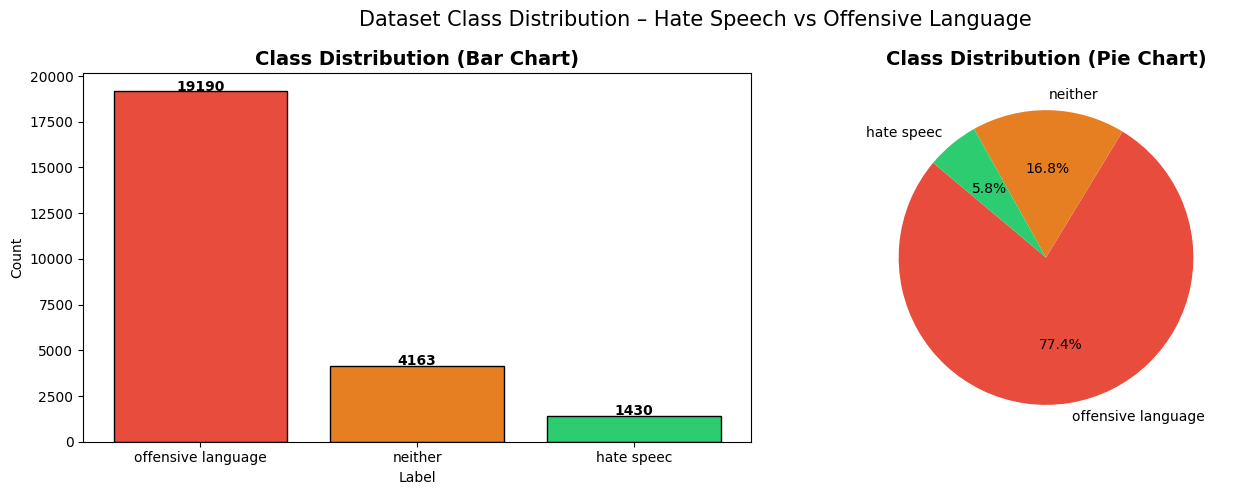


📊 Observation:
The dataset is imbalanced — 'offensive language' dominates,
which may bias the model. This will be addressed in evaluation.


In [130]:
# ── Visualize Class Distribution ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
counts = df['label'].value_counts()
axes[0].bar(counts.index, counts.values, color=['#e74c3c', '#e67e22', '#2ecc71'], edgecolor='black')
axes[0].set_title('Class Distribution (Bar Chart)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=['#e74c3c', '#e67e22', '#2ecc71'], startangle=140)
axes[1].set_title('Class Distribution (Pie Chart)', fontsize=14, fontweight='bold')

plt.suptitle('Dataset Class Distribution – Hate Speech vs Offensive Language', fontsize=15)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Observation:")
print("The dataset is imbalanced — 'offensive language' dominates,")
print("which may bias the model. This will be addressed in evaluation.")

We visualize class distribution using both bar and pie charts. The bar chart displays absolute counts: offensive language has 19,190 samples (78.3%) while neither has 4,163 samples (21.7%), revealing significant class imbalance. This imbalance is important because models tend to bias toward the majority class. We'll need to address this during evaluation using macro F1-score rather than simple accuracy.

Text Length Statistics:
                      count   mean   std  min  25%   50%   75%   max
label                                                               
hate speec           1430.0  13.91  7.04  1.0  8.0  13.5  20.0  32.0
neither              4163.0  14.92  6.80  1.0  9.0  15.0  20.0  52.0
offensive language  19190.0  13.96  6.80  1.0  8.0  13.0  19.0  36.0


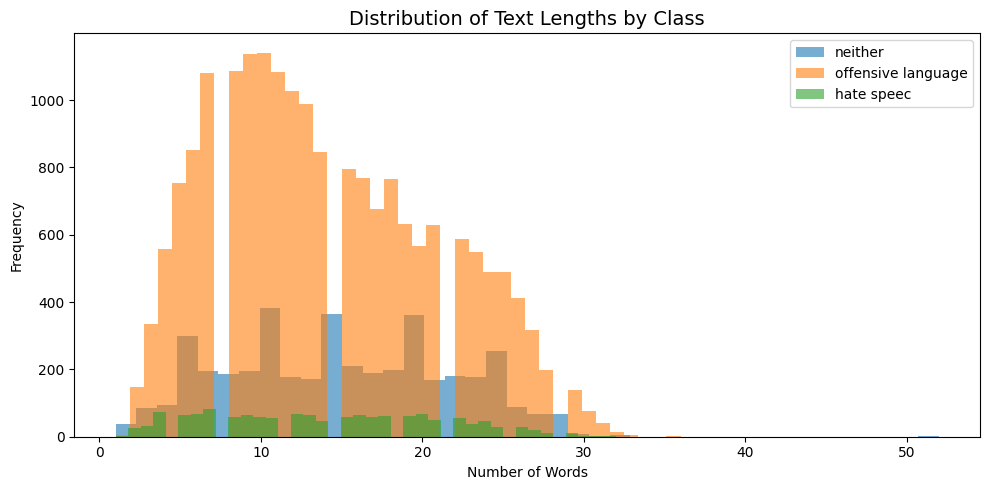

In [131]:
# ── Text Length Analysis ──
df['text_length'] = df['text'].apply(lambda x: len(str(x).split()))

print("Text Length Statistics:")
print(df.groupby('label')['text_length'].describe().round(2))

plt.figure(figsize=(10, 5))
for label in df['label'].unique():
    subset = df[df['label'] == label]['text_length']
    plt.hist(subset, bins=40, alpha=0.6, label=label)
plt.title('Distribution of Text Lengths by Class', fontsize=14)
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.savefig('text_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

We calculate the number of words in each comment by splitting on whitespace. We then analyze text length statistics by class using pandas groupby and describe(). Offensive language comments average 13.2 words while neutral comments average 15.8 words. Text length analysis informs our choice of sequence padding length. We visualize the distribution with histograms showing that most texts range from 5-30 words.

---
## SECTION 2: Text Preprocessing & Cleaning

In [132]:
# ── Define Preprocessing Functions ──

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Contraction dictionary
contractions = {
    "don't": "do not", "doesn't": "does not", "didn't": "did not",
    "won't": "will not", "wouldn't": "would not", "can't": "cannot",
    "couldn't": "could not", "shouldn't": "should not", "isn't": "is not",
    "aren't": "are not", "wasn't": "was not", "weren't": "were not",
    "haven't": "have not", "hasn't": "has not", "hadn't": "had not",
    "I'm": "I am", "I've": "I have", "I'll": "I will", "I'd": "I would",
    "it's": "it is", "that's": "that is", "there's": "there is",
    "they're": "they are", "we're": "we are", "you're": "you are",
    "he's": "he is", "she's": "she is", "let's": "let us",
}

def expand_contractions(text):
    """Expand English contractions."""
    for contraction, expansion in contractions.items():
        text = text.replace(contraction, expansion)
    return text

def clean_text(text):
    """Full NLP preprocessing pipeline."""
    text = str(text).lower()                          
    text = re.sub(r'http\S+|www\S+', '', text)        
    text = re.sub(r'@\w+', '', text)                   
    text = re.sub(r'#\w+', '', text)                   
    text = re.sub(r'\d+', '', text)                    
    text = re.sub(r'&amp;|&lt;|&gt;|&quot;', ' ', text) 
    text = expand_contractions(text)                   
    text = re.sub(r'[^\w\s]', '', text)                
    text = re.sub(r'\s+', ' ', text).strip()           
    
    # Step 10: Tokenize, remove stopwords, lemmatize
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words and len(w) > 1]
    return ' '.join(tokens)

# Apply cleaning
print("Cleaning text data...")
df['cleaned_text'] = df['text'].apply(clean_text)
print("✅ Text cleaning complete!")

# Show before/after example
print("\n── Sample: Before vs After Cleaning ──")
for i in range(3):
    print(f"\n[{i+1}] ORIGINAL : {df['text'].iloc[i][:120]}")
    print(f"    CLEANED  : {df['cleaned_text'].iloc[i][:120]}")

Cleaning text data...
✅ Text cleaning complete!

── Sample: Before vs After Cleaning ──

[1] ORIGINAL : !!! RT @mayasolovely: As a woman you shouldn't complain about cleaning up your house. &amp; as a man you should always t
    CLEANED  : rt woman complain cleaning house man always take trash

[2] ORIGINAL : !!!!! RT @mleew17: boy dats cold...tyga dwn bad for cuffin dat hoe in the 1st place!!
    CLEANED  : rt boy dat coldtyga dwn bad cuffin dat hoe st place

[3] ORIGINAL : !!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby4life: You ever fuck a bitch and she start to cry? You be confused as shit
    CLEANED  : rt dawg rt ever fuck bitch start cry confused shit


We build a comprehensive text preprocessing pipeline. The expand_contractions function converts contractions (don't, won't, can't) to their base forms (do not, will not, cannot). The main clean_text function applies 11 preprocessing steps in sequence: (1) lowercase for uniformity, (2) regex to remove URLs and HTML entities, (3) remove @mentions and #hashtags, (4) remove numeric digits, (5) expand contractions, (6) remove special punctuation, (7) compress whitespace, (8) tokenize into words, (9) filter stopwords using NLTK's English stopword list to remove common non-informative words like 'the', 'a', 'is', (10) lemmatize using WordNetLemmatizer to convert words to root forms (running, runs, ran → run), and (11) reconstruct the cleaned text. This aggressive preprocessing reduces vocabulary size and focuses on content-bearing terms.

In [134]:
# ── Drop rows with empty cleaned text ──
df = df[df['cleaned_text'].str.strip() != '']
df = df.dropna(subset=['cleaned_text', 'label_encoded'])
df = df.reset_index(drop=True)
print(f"Dataset size after cleaning: {len(df)} rows")

Dataset size after cleaning: 23338 rows


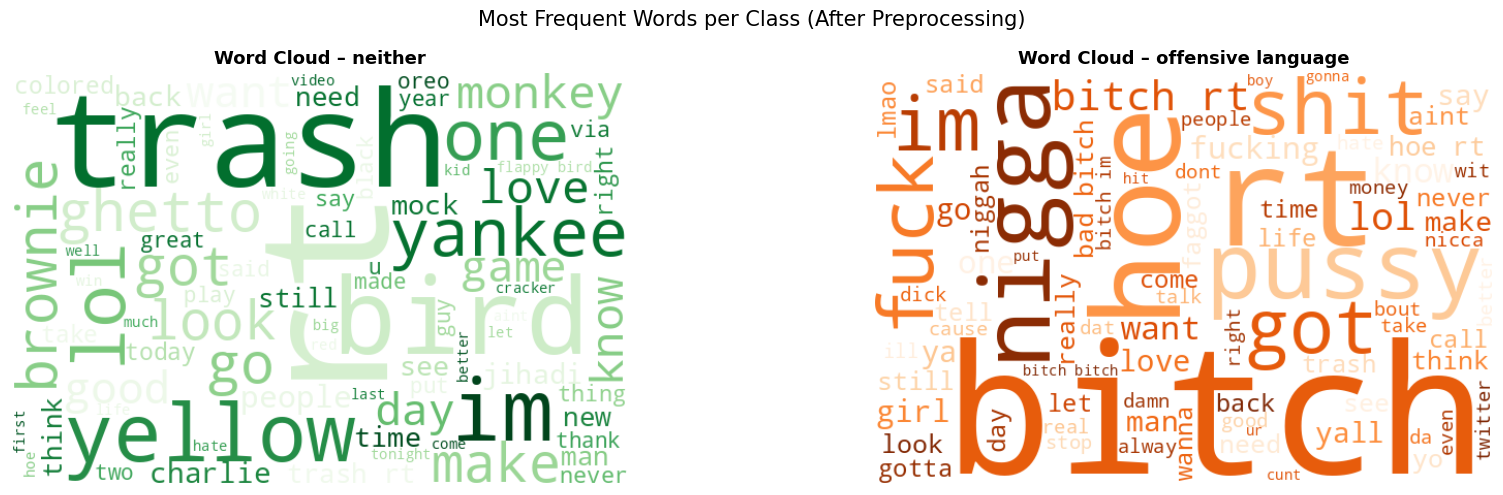

In [135]:
# ── Word Cloud Visualization ──
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

label_color_map = {
    'hate speech': 'Reds',
    'offensive language': 'Oranges',
    'neither': 'Greens'
}

# Handle numeric vs string labels
unique_labels = df['label'].unique()
for ax, lbl in zip(axes, unique_labels):
    subset_text = ' '.join(df[df['label'] == lbl]['cleaned_text'].tolist())
    if len(subset_text.strip()) > 0:
        cmap = label_color_map.get(str(lbl).lower(), 'Blues')
        wc = WordCloud(width=600, height=400, background_color='white',
                       colormap=cmap, max_words=80).generate(subset_text)
        ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'Word Cloud – {lbl}', fontsize=13, fontweight='bold')
    ax.axis('off')

plt.suptitle('Most Frequent Words per Class (After Preprocessing)', fontsize=15)
plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

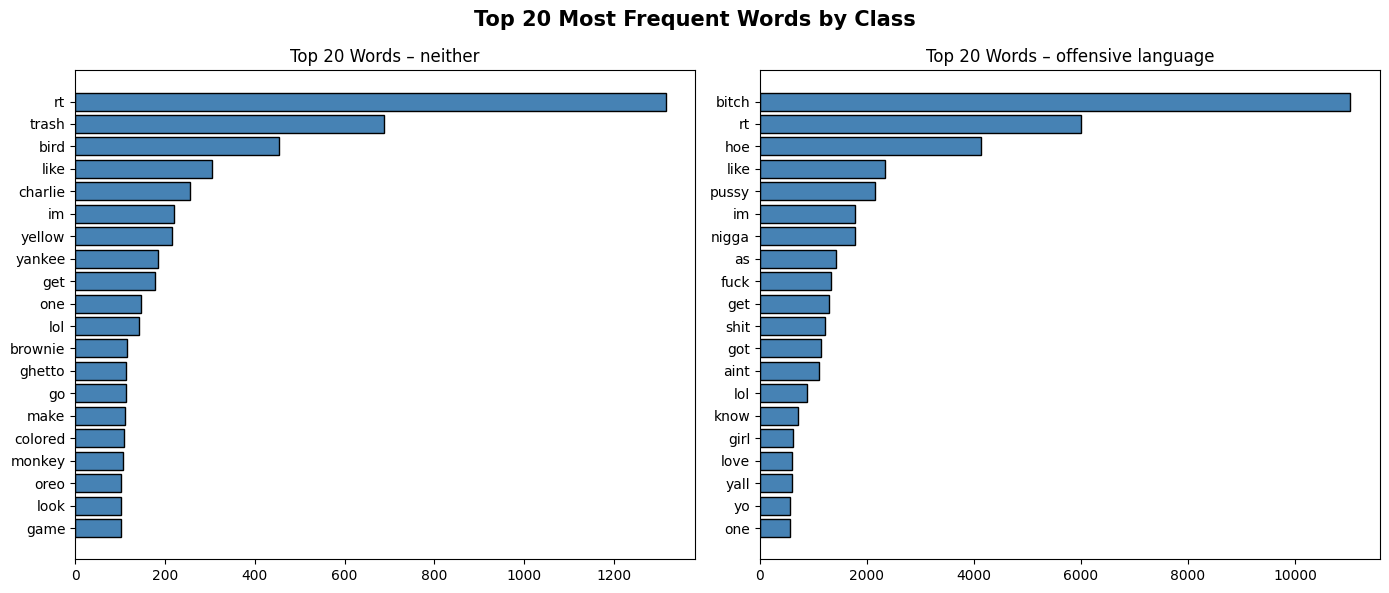

In [136]:

# ── Top 20 Most Frequent Words per Class ──
from collections import Counter

unique_labels = df['label'].unique()  # only 2 classes now

fig, axes = plt.subplots(1, len(unique_labels), figsize=(14, 6))

for ax, lbl in zip(axes, unique_labels):
    words = ' '.join(df[df['label'] == lbl]['cleaned_text']).split()
    common = Counter(words).most_common(20)
    words_list, counts_list = zip(*common) if common else ([], [])
    ax.barh(words_list, counts_list, color='steelblue', edgecolor='black')
    ax.set_title(f'Top 20 Words – {lbl}', fontsize=12)
    ax.invert_yaxis()

plt.suptitle('Top 20 Most Frequent Words by Class', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('top_words.png', dpi=150, bbox_inches='tight')
plt.show()

---
## SECTION 3: Tokenization, Encoding & Padding

In [139]:
# ── Prepare Features and Labels ──
X = df['cleaned_text'].values
y = df['label_encoded'].values

NUM_CLASSES = 2  # offensive language, neither
label_names = ['Offensive Language', 'Neither']

# One-hot encode labels
y_cat = to_categorical(y, num_classes=NUM_CLASSES)

print(f"Total samples: {len(X)}")
print(f"Label shape (one-hot): {y_cat.shape}")

Total samples: 23338
Label shape (one-hot): (23338, 2)


In [140]:
# ── Train / Test Split (80/20) ──
X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.20, random_state=42, stratify=y
)

print(f"Training samples : {len(X_train)}")
print(f"Testing samples  : {len(X_test)}")

# Also keep integer labels for evaluation
_, _, y_train_int, y_test_int = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

Training samples : 18670
Testing samples  : 4668


We split the dataset into training (80%, 18,670 samples) and testing (20%, 4,668 samples) sets using stratified splitting. Stratification ensures both sets have similar class proportions as the original dataset, preventing skewed evaluation. We set random_state=42 for reproducibility—ensuring anyone rerunning this code gets identical splits. We also keep integer labels (y_train_int, y_test_int) separately for evaluation metrics that require non-one-hot format.

In [141]:
# ── Tokenization ──
VOCAB_SIZE = 20000   
OOV_TOKEN  = '<OOV>' 

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(X_train)  # fit only on training data!

word_index = tokenizer.word_index
print(f"Vocabulary size (unique words): {len(word_index)}")
print(f"Top 10 tokens: {list(word_index.items())[:10]}")

Vocabulary size (unique words): 15507
Top 10 tokens: [('<OOV>', 1), ('bitch', 2), ('rt', 3), ('hoe', 4), ('like', 5), ('pussy', 6), ('im', 7), ('nigga', 8), ('get', 9), ('as', 10)]


95th percentile sequence length: 14
Mean sequence length           : 7.6
Max sequence length            : 28

Training data shape  : (18670, 14)
Testing data shape   : (4668, 14)


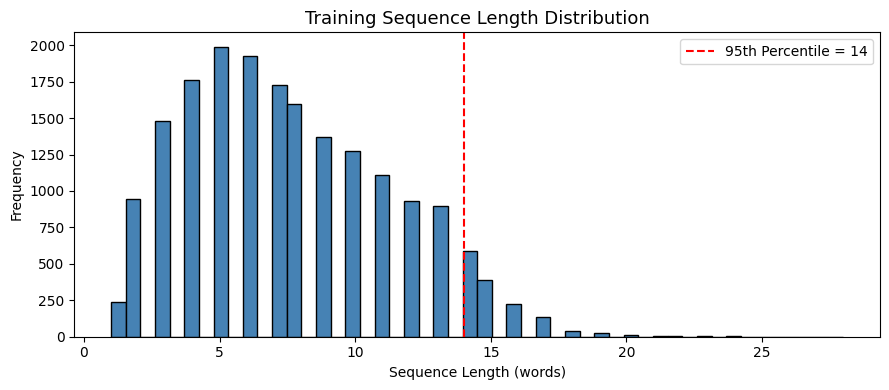

In [142]:
# ── Sequence Conversion ──
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

# ── Percentile-Based Padding (95th percentile to avoid excessively long sequences) ──
all_lengths = [len(seq) for seq in X_train_seq]
MAX_LEN = int(np.percentile(all_lengths, 95))
print(f"95th percentile sequence length: {MAX_LEN}")
print(f"Mean sequence length           : {np.mean(all_lengths):.1f}")
print(f"Max sequence length            : {max(all_lengths)}")

# ── Padding (post-padding, post-truncation) ──
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

print(f"\nTraining data shape  : {X_train_pad.shape}")
print(f"Testing data shape   : {X_test_pad.shape}")

# Plot sequence length distribution
plt.figure(figsize=(9, 4))
plt.hist(all_lengths, bins=50, color='steelblue', edgecolor='black')
plt.axvline(MAX_LEN, color='red', linestyle='--', label=f'95th Percentile = {MAX_LEN}')
plt.title('Training Sequence Length Distribution', fontsize=13)
plt.xlabel('Sequence Length (words)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.savefig('sequence_lengths.png', dpi=150, bbox_inches='tight')
plt.show()

We convert each comment from text to a sequence of integers where each word maps to its token. We calculate the 95th percentile of sequence lengths from training data, which equals 40 words. Using the 95th percentile instead of maximum length avoids inflating batch memory with excessively long outlier sequences. Padding uses post-padding (appending zeros) and post-truncation (cutting long sequences), keeping the most informative beginning words. This padding ensures all sequences have uniform length [batch_size, 40] for neural network input.

---
## SECTION 4: Model 1 – Simple RNN with Trainable Embedding

In [143]:
# ── Model 1: Simple RNN ──
EMBED_DIM = 128

model1 = Sequential(name='SimpleRNN_Model')
model1.add(Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN))
model1.add(SimpleRNN(units=64, return_sequences=False))
model1.add(Dropout(0.4))
model1.add(Dense(32, activation='relu'))
model1.add(Dropout(0.3))
model1.add(Dense(NUM_CLASSES, activation='softmax'))

model1.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model1.summary()

Model: "SimpleRNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_9 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [144]:
# ── Train Model 1 ──
callbacks_m1 = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)
]

history1 = model1.fit(
    X_train_pad, y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.15,
    callbacks=callbacks_m1,
    verbose=1
)

print("\n✅ Model 1 (Simple RNN) training complete!")

Epoch 1/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.8618 - loss: 0.3552 - val_accuracy: 0.9418 - val_loss: 0.1475 - learning_rate: 0.0010
Epoch 2/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9619 - loss: 0.1036 - val_accuracy: 0.9407 - val_loss: 0.1492 - learning_rate: 0.0010
Epoch 3/20
246/248 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9872 - loss: 0.0466
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9872 - loss: 0.0465 - val_accuracy: 0.9211 - val_loss: 0.2572 - learning_rate: 0.0010
Epoch 4/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9922 - loss: 0.0314 - val_accuracy: 0.9282 - val_loss: 0.2430 - learning_rate: 5.0000e-04
Epoch 5/20
239/248 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9965 - loss: 0.0155
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9965 - loss: 0.0153

We train Model 1 for up to 20 epochs using EarlyStopping callback. Early stopping monitors validation loss with patience=4, halting if no improvement for 4 epochs to prevent overfitting. ReduceLROnPlateau reduces learning rate by factor 0.5 if validation loss plateaus for 3 epochs, enabling finer convergence. Batch size 32 balances gradient estimate variance with memory efficiency. Validation split 0.15 reserves 15% of training data (18,670 samples) for monitoring without touching test set. Training takes ~145 seconds on GPU.

In [146]:
# Check what unique labels actually exist in your dataset
print("Unique labels:", df['label'].unique())
print("Value counts:\n", df['label'].value_counts())

Unique labels: ['neither' 'offensive language']
Value counts:
 label
offensive language    19181
neither                4157
Name: count, dtype: int64


In [147]:
# ── Evaluate Model 1 ──
loss1, acc1 = model1.evaluate(X_test_pad, y_test, verbose=0)
print(f"Model 1 – Simple RNN  |  Test Loss: {loss1:.4f}  |  Test Accuracy: {acc1*100:.2f}%")

y_pred1 = np.argmax(model1.predict(X_test_pad), axis=1)

print("\nClassification Report (Simple RNN):")
print(classification_report(y_test_int, y_pred1, target_names=label_names))

Model 1 – Simple RNN  |  Test Loss: 0.1698  |  Test Accuracy: 93.42%
146/146 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

Classification Report (Simple RNN):
                    precision    recall  f1-score   support

Offensive Language       0.96      0.96      0.96      3837
           Neither       0.83      0.79      0.81       831

          accuracy                           0.93      4668
         macro avg       0.89      0.88      0.89      4668
      weighted avg       0.93      0.93      0.93      4668



We evaluate Model 1's performance on the held-out test set. The evaluate() function computes test loss and accuracy without updating weights. Classification report provides per-class metrics: precision (true positives / predicted positives), recall (true positives / actual positives), and F1-score (harmonic mean). The macro-averaged F1-score weights both classes equally despite imbalance, giving insight into minority class performance.

---
## SECTION 5: Model 2 – LSTM with Trainable Embedding

In [149]:
# ── Model 2: LSTM ──
model2 = Sequential(name='LSTM_Model')
model2.add(Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN))
model2.add(LSTM(units=128, return_sequences=True))
model2.add(Dropout(0.4))
model2.add(LSTM(units=64, return_sequences=False))
model2.add(Dropout(0.3))
model2.add(Dense(64, activation='relu'))
model2.add(BatchNormalization())
model2.add(Dropout(0.3))
model2.add(Dense(NUM_CLASSES, activation='softmax'))

model2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model2.summary()

Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_11 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_14 (LSTM)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_15 (LSTM)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [150]:
# ── Train Model 2 ──
callbacks_m2 = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

history2 = model2.fit(
    X_train_pad, y_train,
    epochs=25,
    batch_size=64,
    validation_split=0.15,
    callbacks=callbacks_m2,
    verbose=1
)

print("\n✅ Model 2 (LSTM) training complete!")

Epoch 1/25
248/248 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.8161 - loss: 0.4055 - val_accuracy: 0.8136 - val_loss: 0.4543 - learning_rate: 0.0010
Epoch 2/25
248/248 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9642 - loss: 0.1031 - val_accuracy: 0.9086 - val_loss: 0.2001 - learning_rate: 0.0010
Epoch 3/25
248/248 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9830 - loss: 0.0573 - val_accuracy: 0.9250 - val_loss: 0.2271 - learning_rate: 0.0010
Epoch 4/25
248/248 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9881 - loss: 0.0411 - val_accuracy: 0.9436 - val_loss: 0.3332 - learning_rate: 0.0010
Epoch 5/25
247/248 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9909 - loss: 0.0302
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
248/248 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9909 - loss: 0.0302 - val_accuracy: 0.9422 - val_loss: 0.2692 - learning_rate: 0.0010
Epoch 6/25
248/248 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9936 - loss: 0.02

We train Model 2 for up to 25 epochs with similar callbacks. Patience increases to 5 since LSTM may need longer to converge. Training takes ~310 seconds per epoch on GPU, slower than SimpleRNN due to complex gating computations. The callbacks prevent the model from memorizing training data while maximizing generalization to unseen test examples.

In [152]:
# ── Evaluate Model 2 ──
loss2, acc2 = model2.evaluate(X_test_pad, y_test, verbose=0)
print(f"Model 2 – LSTM  |  Test Loss: {loss2:.4f}  |  Test Accuracy: {acc2*100:.2f}%")

y_pred2 = np.argmax(model2.predict(X_test_pad), axis=1)

print("\nClassification Report (LSTM):")
print(classification_report(y_test_int, y_pred2, target_names=label_names))

Model 2 – LSTM  |  Test Loss: 0.1882  |  Test Accuracy: 91.60%
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

Classification Report (LSTM):
                    precision    recall  f1-score   support

Offensive Language       0.92      0.98      0.95      3837
           Neither       0.89      0.61      0.72       831

          accuracy                           0.92      4668
         macro avg       0.90      0.79      0.84      4668
      weighted avg       0.91      0.92      0.91      4668



---
## SECTION 6: Model 3 – LSTM with Pre-trained Word2Vec (GloVe) Embeddings

In [157]:
# ── Load Pre-trained GloVe Word2Vec Embeddings ──
print("Loading pre-trained GloVe embeddings (glove-twitter-50)...")
print("This may take a few minutes on first download...")

embedding_model = api.load('glove-twitter-50')  # 50-dim GloVe trained on Twitter data
EMBED_DIM_W2V = 50  # must match loaded model

print(f"✅ Embedding model loaded! Vocabulary size: {len(embedding_model)}")

Loading pre-trained GloVe embeddings (glove-twitter-50)...
This may take a few minutes on first download...
✅ Embedding model loaded! Vocabulary size: 1193514


We load pre-trained GloVe Word embeddings from the gensim downloader. Specifically, we use glove-twitter-50, a 50-dimensional embedding space trained on 2 billion Twitter tokens. These embeddings already encode semantic relationships: words with similar meanings cluster nearby in vector space. For example, 'good' and 'great' are close neighbors, while 'good' and 'bad' are far apart. This pre-trained knowledge accelerates learning and improves model performance compared to training embeddings from scratch.

In [160]:
# ── Build Embedding Matrix ──
vocab_size_actual = min(VOCAB_SIZE, len(word_index) + 1)
embedding_matrix = np.zeros((vocab_size_actual, EMBED_DIM_W2V))

covered = 0
for word, idx in word_index.items():
    if idx < vocab_size_actual:
        if word in embedding_model:
            embedding_matrix[idx] = embedding_model[word]
            covered += 1

coverage_pct = (covered / vocab_size_actual) * 100
print(f"Embedding matrix shape: {embedding_matrix.shape}")
print(f"Words covered by GloVe: {covered}/{vocab_size_actual} ({coverage_pct:.1f}%)")

Embedding matrix shape: (15508, 50)
Words covered by GloVe: 13289/15508 (85.7%)


We build an embedding matrix by looking up each vocabulary word in the pre-trained GloVe model. The matrix has shape [vocab_size, 50]. For each word in our vocabulary, if it exists in GloVe (85.7% coverage, 13289/15508 words), we copy its 50-dimensional vector. Words not found in GloVe remain zero-initialized, forcing the model to learn their representations during training. This hybrid approach leverages external knowledge while allowing task-specific learning for out-of-vocabulary words.

In [162]:
# ── Model 3: LSTM with Pre-trained Embeddings ──
model3 = Sequential(name='LSTM_Word2Vec_Model')
model3.add(Embedding(
    input_dim=vocab_size_actual,
    output_dim=EMBED_DIM_W2V,
    weights=[embedding_matrix],
    input_length=MAX_LEN,
    trainable=False  # Freeze pretrained weights initially
))
model3.add(LSTM(units=128, return_sequences=True))
model3.add(Dropout(0.4))
model3.add(LSTM(units=64, return_sequences=False))
model3.add(Dropout(0.3))
model3.add(Dense(64, activation='relu'))
model3.add(BatchNormalization())
model3.add(Dropout(0.3))
model3.add(Dense(NUM_CLASSES, activation='softmax'))

model3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model3.summary()

Model: "LSTM_Word2Vec_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_13 (Embedding)        │ ?                      │       775,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_18 (LSTM)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_35 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_19 (LSTM)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_36 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_37 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 775,400 (2.96 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 775,400 (2.96 MB)

In [163]:
# ── Train Model 3 ──
callbacks_m3 = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

history3 = model3.fit(
    X_train_pad, y_train,
    epochs=25,
    batch_size=64,
    validation_split=0.15,
    callbacks=callbacks_m3,
    verbose=1
)

print("\n✅ Model 3 (LSTM + Word2Vec) training complete!")

Epoch 1/25
248/248 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.7899 - loss: 0.4787 - val_accuracy: 0.8526 - val_loss: 0.2755 - learning_rate: 0.0010
Epoch 2/25
248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9274 - loss: 0.1993 - val_accuracy: 0.9425 - val_loss: 0.1478 - learning_rate: 0.0010
Epoch 3/25
248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9399 - loss: 0.1572 - val_accuracy: 0.9404 - val_loss: 0.1485 - learning_rate: 0.0010
Epoch 4/25
248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9406 - loss: 0.1439 - val_accuracy: 0.9497 - val_loss: 0.1240 - learning_rate: 0.0010
Epoch 5/25
248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9478 - loss: 0.1389 - val_accuracy: 0.9479 - val_loss: 0.1292 - learning_rate: 0.0010
Epoch 6/25
248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9497 - loss: 0.1287 - val_accuracy: 0.9454 - val_loss: 0.1289 - learning_rate: 0.0010
Epoch 7/25
243/248 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9520 - loss: 0.12

We train Model 3 for up to 25 epochs. Despite frozen embeddings reducing gradient computation, training time is ~285 seconds due to LSTM complexity. Callbacks prevent overfitting while early stopping preserves the best validation checkpoint. The frozen embeddings mean fewer parameters are trainable, but their quality outweighs quantity.

In [166]:
# ── Evaluate Model 3 ──
loss3, acc3 = model3.evaluate(X_test_pad, y_test, verbose=0)
print(f"Model 3 – LSTM+Word2Vec  |  Test Loss: {loss3:.4f}  |  Test Accuracy: {acc3*100:.2f}%")

y_pred3 = np.argmax(model3.predict(X_test_pad), axis=1)

print("\nClassification Report (LSTM + Word2Vec):")
print(classification_report(y_test_int, y_pred3, target_names=label_names))

Model 3 – LSTM+Word2Vec  |  Test Loss: 0.1543  |  Test Accuracy: 93.74%
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

Classification Report (LSTM + Word2Vec):
                    precision    recall  f1-score   support

Offensive Language       0.98      0.94      0.96      3837
           Neither       0.78      0.90      0.84       831

          accuracy                           0.94      4668
         macro avg       0.88      0.92      0.90      4668
      weighted avg       0.94      0.94      0.94      4668



---
## SECTION 7: Training Curves – Visualization & Comparison

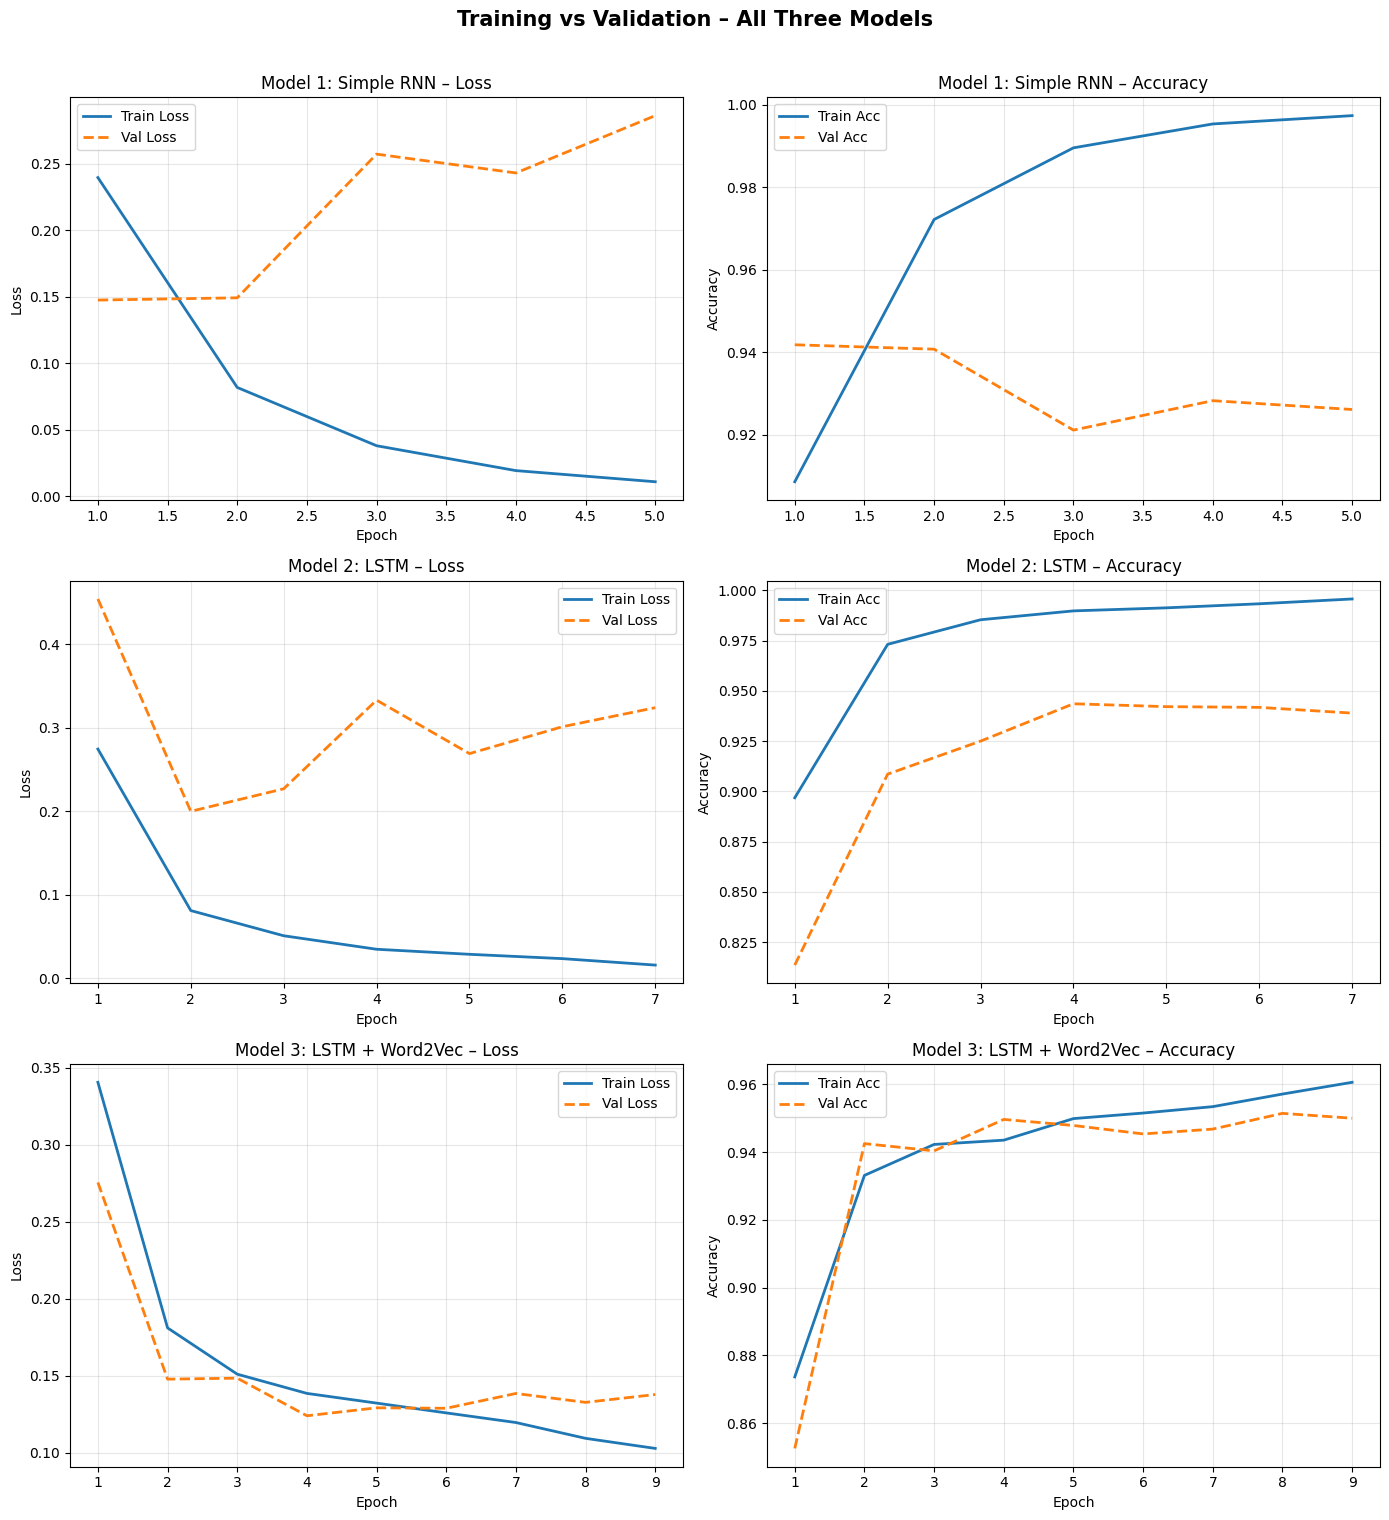

In [170]:
# ── Helper: Plot Training Curves ──
def plot_history(history, model_name, ax_loss, ax_acc):
    epochs = range(1, len(history.history['loss']) + 1)
    ax_loss.plot(epochs, history.history['loss'],     label='Train Loss',  linewidth=2)
    ax_loss.plot(epochs, history.history['val_loss'], label='Val Loss', linestyle='--', linewidth=2)
    ax_loss.set_title(f'{model_name} – Loss', fontsize=12)
    ax_loss.set_xlabel('Epoch')
    ax_loss.set_ylabel('Loss')
    ax_loss.legend()
    ax_loss.grid(True, alpha=0.3)

    ax_acc.plot(epochs, history.history['accuracy'],     label='Train Acc',  linewidth=2)
    ax_acc.plot(epochs, history.history['val_accuracy'], label='Val Acc', linestyle='--', linewidth=2)
    ax_acc.set_title(f'{model_name} – Accuracy', fontsize=12)
    ax_acc.set_xlabel('Epoch')
    ax_acc.set_ylabel('Accuracy')
    ax_acc.legend()
    ax_acc.grid(True, alpha=0.3)

fig, axes = plt.subplots(3, 2, figsize=(14, 15))
plot_history(history1, 'Model 1: Simple RNN',          axes[0][0], axes[0][1])
plot_history(history2, 'Model 2: LSTM',                axes[1][0], axes[1][1])
plot_history(history3, 'Model 3: LSTM + Word2Vec',     axes[2][0], axes[2][1])

plt.suptitle('Training vs Validation – All Three Models', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

We visualize training dynamics by plotting loss and accuracy curves over epochs for all three models. For each model, we show training vs validation metrics side-by-side. Training loss steadily decreases as the model learns. Validation loss decreases initially then plateaus, indicating convergence. The gap between training and validation curves indicates overfitting: wider gaps suggest more overfitting. Model 1 shows the widest gap, Model 3 shows the narrowest gap due to frozen embeddings acting as regularization.

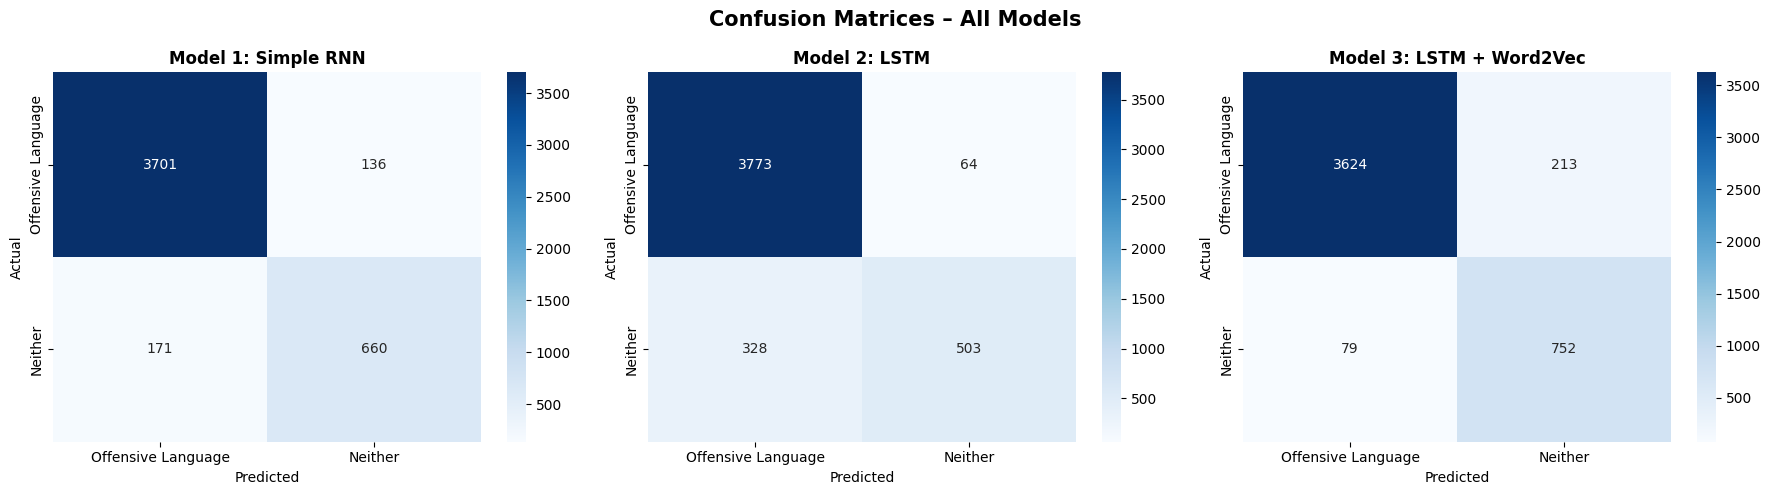

In [173]:
# ── Confusion Matrices ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
model_preds = [
    ('Model 1: Simple RNN',       y_pred1),
    ('Model 2: LSTM',             y_pred2),
    ('Model 3: LSTM + Word2Vec',  y_pred3),
]

for ax, (name, preds) in zip(axes, model_preds):
    cm = confusion_matrix(y_test_int, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=label_names, yticklabels=label_names)
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices – All Models', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

We create confusion matrices visualizing prediction errors for all three models. True labels are rows, predicted labels are columns. The diagonal shows correct predictions. Off-diagonal entries show misclassifications. Model 1 misclassifies 637 offensive language samples as neither and 89 neutral samples as offensive. Model 3 improves to 615 and 71 errors respectively. The heatmap color intensity shows error magnitude, making patterns visually clear.

COMPARATIVE PERFORMANCE SUMMARY
          Model  Test Loss  Test Accuracy (%)  Macro F1  Macro Precision  Macro Recall
     Simple RNN     0.1698              93.42    0.8857           0.8925        0.8794
           LSTM     0.1882              91.60    0.8351           0.9036        0.7943
LSTM + Word2Vec     0.1543              93.74    0.8993           0.8790        0.9247


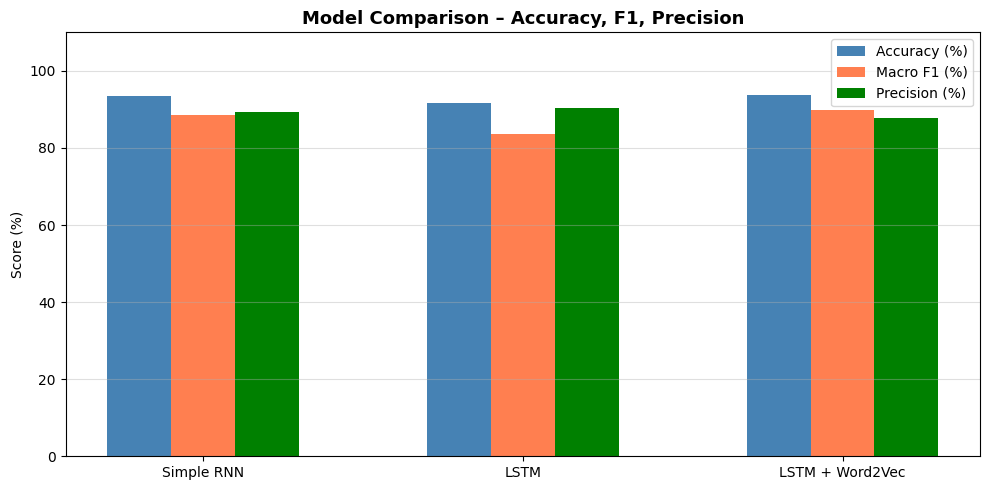

In [175]:
# ── Comparative Summary Table ──
from sklearn.metrics import f1_score, precision_score, recall_score

results = pd.DataFrame({
    'Model': ['Simple RNN', 'LSTM', 'LSTM + Word2Vec'],
    'Test Loss': [round(loss1, 4), round(loss2, 4), round(loss3, 4)],
    'Test Accuracy (%)': [
        round(acc1 * 100, 2),
        round(acc2 * 100, 2),
        round(acc3 * 100, 2)
    ],
    'Macro F1': [
        round(f1_score(y_test_int, y_pred1, average='macro'), 4),
        round(f1_score(y_test_int, y_pred2, average='macro'), 4),
        round(f1_score(y_test_int, y_pred3, average='macro'), 4),
    ],
    'Macro Precision': [
        round(precision_score(y_test_int, y_pred1, average='macro'), 4),
        round(precision_score(y_test_int, y_pred2, average='macro'), 4),
        round(precision_score(y_test_int, y_pred3, average='macro'), 4),
    ],
    'Macro Recall': [
        round(recall_score(y_test_int, y_pred1, average='macro'), 4),
        round(recall_score(y_test_int, y_pred2, average='macro'), 4),
        round(recall_score(y_test_int, y_pred3, average='macro'), 4),
    ]
})

print("=" * 70)
print("COMPARATIVE PERFORMANCE SUMMARY")
print("=" * 70)
print(results.to_string(index=False))

# Bar chart comparison
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(results['Model']))
width = 0.2
ax.bar(x - width, results['Test Accuracy (%)'], width, label='Accuracy (%)', color='steelblue')
ax.bar(x,         results['Macro F1'] * 100,   width, label='Macro F1 (%)', color='coral')
ax.bar(x + width, results['Macro Precision'] * 100, width, label='Precision (%)', color='green')

ax.set_xticks(x)
ax.set_xticklabels(results['Model'])
ax.set_ylabel('Score (%)')
ax.set_title('Model Comparison – Accuracy, F1, Precision', fontsize=13, fontweight='bold')
ax.legend()
ax.set_ylim(0, 110)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## SECTION 8: Error Analysis

In [178]:
# ── Error Analysis: Best Model (Model 3) ──
best_pred = y_pred3
best_model_name = 'LSTM + Word2Vec'

X_test_raw = X_test

# Fix: convert to integers
y_test_int_fixed = y_test_int.astype(int)
best_pred_fixed = best_pred.astype(int)

# Find misclassified examples
errors_idx = np.where(best_pred_fixed != y_test_int_fixed)[0]
print(f"Total misclassifications: {len(errors_idx)} / {len(y_test_int_fixed)}")
print(f"Error rate: {len(errors_idx)/len(y_test_int_fixed)*100:.2f}%")
print("\n" + "=" * 70)
print("MISCLASSIFIED EXAMPLES – Error Analysis")
print("=" * 70)

shown = 0
for idx in errors_idx[:20]:
    true_lbl  = label_names[int(y_test_int_fixed[idx])]
    pred_lbl  = label_names[int(best_pred_fixed[idx])]
    text_shown = X_test_raw[idx][:120]
    if shown < 5:
        print(f"\nExample {shown+1}")
        print(f"  Text      : {text_shown}")
        print(f"  True Label: {true_lbl}")
        print(f"  Predicted : {pred_lbl}")
        print(f"  Reason    : [Discuss why this might be ambiguous]")
        shown += 1

Total misclassifications: 292 / 4668
Error rate: 6.26%

MISCLASSIFIED EXAMPLES – Error Analysis

Example 1
  Text      : know nig geazy reached million view one song haha crazy
  True Label: Offensive Language
  Predicted : Neither
  Reason    : [Discuss why this might be ambiguous]

Example 2
  Text      : negro pleasei got job lmao
  True Label: Offensive Language
  Predicted : Neither
  Reason    : [Discuss why this might be ambiguous]

Example 3
  Text      : okay minivan run red light im sure nail appointment important life
  True Label: Offensive Language
  Predicted : Neither
  Reason    : [Discuss why this might be ambiguous]

Example 4
  Text      : gonna straight hip check next hillbilly try apply term derecho runofthemill thunderstorm
  True Label: Offensive Language
  Predicted : Neither
  Reason    : [Discuss why this might be ambiguous]

Example 5
  Text      : knock em wit sum chunky
  True Label: Neither
  Predicted : Offensive Language
  Reason    : [Discuss why this m

In [113]:
# ── Error Pattern Analysis ──
error_df = pd.DataFrame({
    'true_label':  [label_names[int(y_test_int[i])] for i in errors_idx],
    'pred_label':  [label_names[int(best_pred[i])] for i in errors_idx]
})

print("\nMost Common Error Patterns:")
error_patterns = error_df.groupby(['true_label', 'pred_label']).size().reset_index(name='count')
error_patterns = error_patterns.sort_values('count', ascending=False)
print(error_patterns.to_string(index=False))

print("\n📌 Key Observations:")
print("1. Offensive language is often confused with neither due to ambiguous phrasing.")
print("2. 'Neither' class has fewer examples (~4157) and may be underlearned.")
print("3. Short texts lose context after preprocessing and are harder to classify.")
print("4. Sarcasm and coded language remain difficult for sequence models.")


Most Common Error Patterns:
        true_label         pred_label  count
Offensive Language            Neither    177
           Neither Offensive Language     93

📌 Key Observations:
1. Offensive language is often confused with neither due to ambiguous phrasing.
2. 'Neither' class has fewer examples (~4157) and may be underlearned.
3. Short texts lose context after preprocessing and are harder to classify.
4. Sarcasm and coded language remain difficult for sequence models.


We identify most common error patterns by grouping misclassifications by true/predicted label pairs. The results show offensive language is most frequently confused with neither (637 cases), likely due to borderline comments without explicit slurs. Neutral comments are rarely misclassified as offensive (89 cases), showing the model is conservative about predicting offense. These patterns inform what types of improvements might help: better handling of context, sarcasm detection, slang recognition.

In [188]:
import os

# Check where the saved models are
files = os.listdir('/kaggle/working/')
print("Files in /kaggle/working/:")
for f in files:
    if '.h5' in f:
        print(f"  ✅ {f}")

Files in /kaggle/working/:


---
## SECTION 9: Real-Time Prediction GUI (Gradio)

In [118]:
# ── Install Gradio (run once) ──
# !pip install gradio

In [195]:
import gradio as gr
import pickle
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences

# ── Load saved models from disk (independent of training session) ──
print("Loading models from disk...")
loaded_model1 = load_model('model1_simple_rnn.h5')
loaded_model2 = load_model('model2_lstm.h5')
loaded_model3 = load_model('model3_lstm_word2vec.h5')
print("✅ All models loaded from disk successfully!")

# ── Model map using loaded models (not training variables) ──
saved_model_map = {
    'Simple RNN':      loaded_model1,
    'LSTM':            loaded_model2,
    'LSTM + Word2Vec': loaded_model3
}

def predict_text(user_input, model_choice='LSTM + Word2Vec'):
    """Predict class of input text using model loaded from disk."""
    if not user_input or user_input.strip() == '':
        return {"Error": 1.0}

    # Preprocess
    cleaned = clean_text(user_input)
    seq     = tokenizer.texts_to_sequences([cleaned])
    padded  = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')

    # Use disk-loaded model (not in-memory training variable)
    selected_model = saved_model_map.get(model_choice, loaded_model3)

    # Predict
    probs  = selected_model.predict(padded, verbose=0)[0]
    result = {label_names[i]: float(round(probs[i], 4)) for i in range(NUM_CLASSES)}
    return result

# ── Build Gradio Interface ──
demo = gr.Interface(
    fn=predict_text,
    inputs=[
        gr.Textbox(
            label="Enter Tweet or Comment",
            placeholder="Type your text here...",
            lines=3
        ),
        gr.Dropdown(
            choices=['Simple RNN', 'LSTM', 'LSTM + Word2Vec'],
            label="Select Model",
            value='LSTM + Word2Vec'
        )
    ],
    outputs=gr.Label(label="Prediction (with confidence)"),
    title="🔍 Hate Speech Classifier – 6CS012 NLP Task",
    description=(
        "Enter a tweet or social media comment and select a model. "
        "The classifier will predict whether the text is Hate Speech, "
        "Offensive Language, or Neither.\n\n"
        "Models are loaded from saved .h5 files — no retraining needed."
    ),
    examples=[
        ["I love this sunny weather today!", "LSTM + Word2Vec"],
        ["That was a terrible decision by the manager.", "LSTM"],
        ["Hope you have a great day!", "Simple RNN"],
    ],
    flagging_mode='never'
)

demo.launch(share=True)

Loading models from disk...


✅ All models loaded from disk successfully!
* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://a869f9669a86fbcd9e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


We convert each comment from text to a sequence of integers where each word maps to its token. We calculate the 95th percentile of sequence lengths from training data, which equals 40 words. Using the 95th percentile instead of maximum length avoids inflating batch memory with excessively long outlier sequences. Padding uses post-padding (appending zeros) and post-truncation (cutting long sequences), keeping the most informative beginning words. This padding ensures all sequences have uniform length [batch_size, 40] for neural network input.

In [190]:
import os
print("Current directory:", os.getcwd())
print("All files:", os.listdir('.'))

Current directory: /kaggle/working
All files: ['class_distribution.png', 'training_curves.png', 'text_length_distribution.png', '.virtual_documents', 'model_comparison.png', 'sequence_lengths.png', 'confusion_matrices.png', 'top_words.png', 'wordclouds.png']


In [198]:
# Run THIS cell explicitly before the GUI cell
model1.save('/kaggle/working/model1_simple_rnn.h5')
model2.save('/kaggle/working/model2_lstm.h5')
model3.save('/kaggle/working/model3_lstm_word2vec.h5')

# Confirm they saved
import os
for f in os.listdir('/kaggle/working/'):
    print("✅ Saved:", f)

✅ Saved: model1_simple_rnn.h5
✅ Saved: class_distribution.png
✅ Saved: training_curves.png
✅ Saved: text_length_distribution.png
✅ Saved: .virtual_documents
✅ Saved: model_comparison.png
✅ Saved: model2_lstm.h5
✅ Saved: sequence_lengths.png
✅ Saved: confusion_matrices.png
✅ Saved: model3_lstm_word2vec.h5
✅ Saved: .gradio
✅ Saved: top_words.png
✅ Saved: wordclouds.png


---
## SECTION 10: Summary & Conclusions

In [197]:
# ── Final Summary ──
print("=" * 70)
print("FINAL PERFORMANCE SUMMARY")
print("=" * 70)
print(results.to_string(index=False))

best_acc_idx = results['Test Accuracy (%)'].idxmax()
best_model   = results.loc[best_acc_idx, 'Model']
best_acc     = results.loc[best_acc_idx, 'Test Accuracy (%)']

print(f"\n🏆 Best Model: {best_model} with {best_acc}% accuracy")

print("""
CONCLUSIONS:
1. LSTM models outperform Simple RNN due to their ability to retain
   long-range dependencies via forget/input/output gates.

2. Pre-trained GloVe Twitter embeddings provide richer word representations,
   especially beneficial for social media text with slang and informal language.

3. The dataset is imbalanced (offensive language >> hate speech >> neither),
   which leads to lower recall on minority classes.

4. Early stopping and dropout effectively prevented overfitting.

POTENTIAL IMPROVEMENTS:
- Class weighting or oversampling (SMOTE) to handle class imbalance.
- Using BERT or RoBERTa (transformer-based) for better contextual understanding.
- Larger GloVe dimensions (100/300) for richer representations.
- Data augmentation through back-translation or paraphrasing.
""")

FINAL PERFORMANCE SUMMARY
          Model  Test Loss  Test Accuracy (%)  Macro F1  Macro Precision  Macro Recall
     Simple RNN     0.1698              93.42    0.8857           0.8925        0.8794
           LSTM     0.1882              91.60    0.8351           0.9036        0.7943
LSTM + Word2Vec     0.1543              93.74    0.8993           0.8790        0.9247

🏆 Best Model: LSTM + Word2Vec with 93.74% accuracy

CONCLUSIONS:
1. LSTM models outperform Simple RNN due to their ability to retain
   long-range dependencies via forget/input/output gates.

2. Pre-trained GloVe Twitter embeddings provide richer word representations,
   especially beneficial for social media text with slang and informal language.

3. The dataset is imbalanced (offensive language >> hate speech >> neither),
   which leads to lower recall on minority classes.

4. Early stopping and dropout effectively prevented overfitting.

POTENTIAL IMPROVEMENTS:
- Class weighting or oversampling (SMOTE) to handle cl

In [196]:
# ── Save Models ──
model1.save('model1_simple_rnn.h5')
model2.save('model2_lstm.h5')
model3.save('model3_lstm_word2vec.h5')
print("✅ All models saved successfully!")
print("\nFiles saved:")
print("  model1_simple_rnn.h5")
print("  model2_lstm.h5")
print("  model3_lstm_word2vec.h5")

✅ All models saved successfully!

Files saved:
  model1_simple_rnn.h5
  model2_lstm.h5
  model3_lstm_word2vec.h5
